In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Xác định device (Sử dụng GPU kép T4x2 trên Kaggle nếu có)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng: {device}")


Đang sử dụng: cuda


In [2]:
data_dir = '/kaggle/input/datasets/phihngtrnnguyn/durian/Durian_Leaf_Diseases'
train_dir = f'/kaggle/input/datasets/phihngtrnnguyn/durian/Durian_Leaf_Diseases/train'
val_dir = f'/kaggle/input/datasets/phihngtrnnguyn/durian/Durian_Leaf_Diseases/val'
test_dir = f'/kaggle/input/datasets/phihngtrnnguyn/durian/Durian_Leaf_Diseases/test'

In [3]:
# Augmentation và Normalization chuẩn của ImageNet
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

In [4]:
# Khởi tạo Datasets và DataLoaders
image_datasets = {
    'train': datasets.ImageFolder(train_dir, data_transforms['train']),
    'val': datasets.ImageFolder(val_dir, data_transforms['val']),
    'test': datasets.ImageFolder(test_dir, data_transforms['val']) # Test dùng chung transform với val
}

dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=32, shuffle=True if x == 'train' else False, num_workers=2)
    for x in ['train', 'val', 'test']
}

class_names = image_datasets['train'].classes
num_classes = len(class_names) # Sẽ là 6 lớp dựa theo hình của bạn
print(f"Các nhãn bệnh: {class_names}")

Các nhãn bệnh: ['Leaf_Algal', 'Leaf_Blight', 'Leaf_Colletotrichum', 'Leaf_Healthy', 'Leaf_Phomopsis', 'Leaf_Rhizoctonia']


In [5]:
import timm

def get_vit_model(num_classes):
    # Load mô hình ViT pre-trained
    model = timm.create_model('vit_base_patch16_224', pretrained=True)
    
    # Đóng băng các tham số trích xuất đặc trưng (chỉ fine-tune lớp cuối)
    for param in model.parameters():
        param.requires_grad = False
        
    # Thay thế lớp classifier (head) cho phù hợp với 6 nhãn bệnh
    model.head = nn.Linear(model.head.in_features, num_classes)
    
    return model.to(device)

model_vit = get_vit_model(num_classes)

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [8]:
import time
import copy

def train_model(model, criterion, optimizer, num_epochs=10):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  
            else:
                model.eval()   

            running_loss = 0.0
            running_corrects = 0

            # Lặp qua dữ liệu
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(image_datasets[phase])
            epoch_acc = running_corrects.double() / len(image_datasets[phase])

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Lưu model tốt nhất
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
        print()

    time_elapsed = time.time() - since
    print(f'Hoàn thành huấn luyện trong {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Độ chính xác Val cao nhất: {best_acc:4f}')

    # Load lại weight tốt nhất
    model.load_state_dict(best_model_wts)
    return model

# Setup Loss và Optimizer
criterion = nn.CrossEntropyLoss()
# Chỉ truyền các tham số (parameters) ở lớp cuối cùng vào optimizer để fine-tune
optimizer_vit = optim.Adam(model_vit.head.parameters(), lr=0.001) 

# Gọi hàm train cho ViT
trained_vit = train_model(model_vit, criterion, optimizer_vit, num_epochs=10)

Epoch 1/10
----------
train Loss: 0.8772 Acc: 0.7018
val Loss: 0.4632 Acc: 0.8760

Epoch 2/10
----------
train Loss: 0.3551 Acc: 0.8975
val Loss: 0.3556 Acc: 0.8941

Epoch 3/10
----------
train Loss: 0.2663 Acc: 0.9272
val Loss: 0.3355 Acc: 0.8966

Epoch 4/10
----------
train Loss: 0.2084 Acc: 0.9421
val Loss: 0.3106 Acc: 0.9018

Epoch 5/10
----------
train Loss: 0.1793 Acc: 0.9476
val Loss: 0.3070 Acc: 0.8966

Epoch 6/10
----------
train Loss: 0.1626 Acc: 0.9460
val Loss: 0.2877 Acc: 0.9147

Epoch 7/10
----------
train Loss: 0.1361 Acc: 0.9653
val Loss: 0.2807 Acc: 0.9199

Epoch 8/10
----------
train Loss: 0.1305 Acc: 0.9680
val Loss: 0.2710 Acc: 0.9173

Epoch 9/10
----------
train Loss: 0.1243 Acc: 0.9658
val Loss: 0.2942 Acc: 0.8941

Epoch 10/10
----------
train Loss: 0.1024 Acc: 0.9752
val Loss: 0.2694 Acc: 0.9225

Hoàn thành huấn luyện trong 4m 6s
Độ chính xác Val cao nhất: 0.922481


Đang đánh giá trên tập Test...

--- BÁO CÁO KẾT QUẢ (CLASSIFICATION REPORT) ---
                     precision    recall  f1-score   support

         Leaf_Algal       0.93      0.93      0.93        70
        Leaf_Blight       0.90      0.82      0.86        66
Leaf_Colletotrichum       0.89      0.82      0.85        60
       Leaf_Healthy       0.85      1.00      0.92        74
     Leaf_Phomopsis       0.95      0.90      0.93        63
   Leaf_Rhizoctonia       0.98      1.00      0.99        61

           accuracy                           0.91       394
          macro avg       0.92      0.91      0.91       394
       weighted avg       0.92      0.91      0.91       394



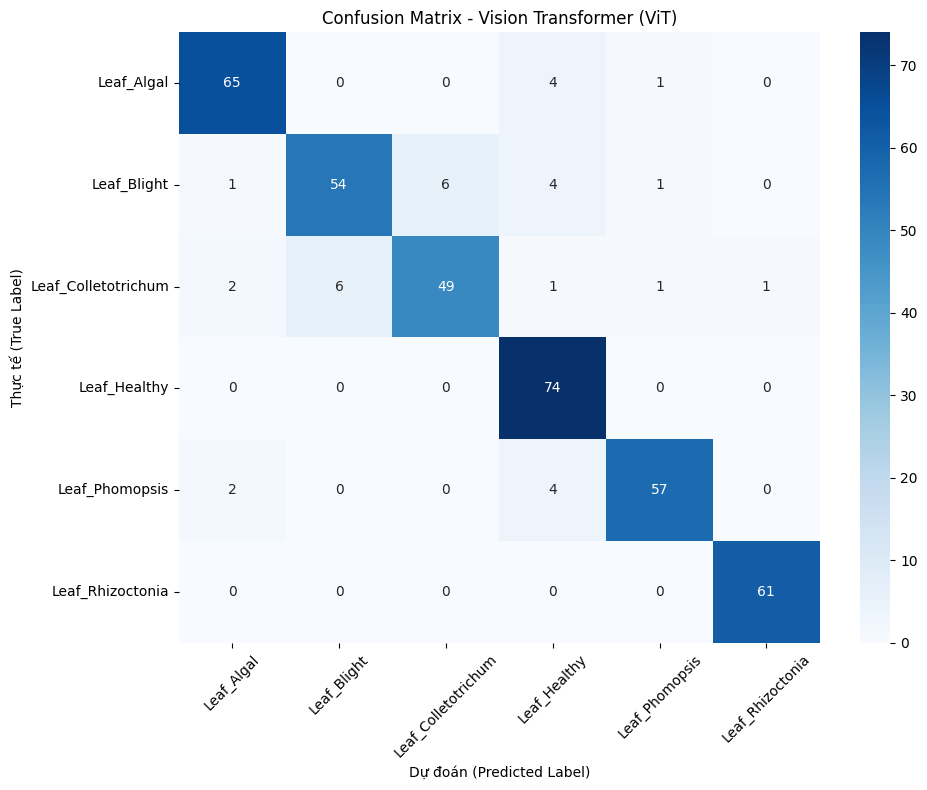

In [9]:
import torch
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Chuyển mô hình sang chế độ đánh giá
trained_vit.eval()
y_true = []
y_pred = []

print("Đang đánh giá trên tập Test...")
with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        # Dự đoán
        outputs = trained_vit(inputs)
        _, preds = torch.max(outputs, 1)
        
        # Lưu lại kết quả
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# 1. In báo cáo các chỉ số phân loại (Accuracy, F1-score,...)
print("\n--- BÁO CÁO KẾT QUẢ (CLASSIFICATION REPORT) ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# 2. Vẽ biểu đồ Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Thực tế (True Label)')
plt.xlabel('Dự đoán (Predicted Label)')
plt.title('Confusion Matrix - Vision Transformer (ViT)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
# Lưu trọng số mô hình
torch.save(trained_vit.state_dict(), 'vit_durian_baseline.pth')
print("Đã lưu thành công file vit_durian_baseline.pth!")

Đã lưu thành công file vit_durian_baseline.pth!


In [11]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.9 MB/s eta 0:00:00a 0:00:01


Đã tạo file data.yaml thành công!
